# Pesudocode Framework For R-LayerNorm

In [ ]:
# robust_layernorm.py
import torch
import torch.nn as nn

class RobustLayerNorm(nn.Module):
    """
    R-LayerNorm: LayerNorm with adaptive noise suppression.
    Combines statistical normalization with entropy-based noise weighting.
    """
    def __init__(self, normalized_shape, epsilon=1e-5, lambda_init=0.1):
        super().__init__()
        # Standard LayerNorm parameters
        self.gamma = nn.Parameter(torch.ones(normalized_shape))
        self.beta = nn.Parameter(torch.zeros(normalized_shape))

        # R-LayerNorm specific: noise sensitivity parameter
        self.lambda_param = nn.Parameter(torch.tensor(lambda_init))
        self.epsilon = epsilon

        # Local entropy estimator (fixed, non-learnable)
        self.is_2d = len(normalized_shape) > 1
        if self.is_2d:
            # For images: simple average pooling for local variance
            self.avg_pool = nn.AvgPool2d(3, stride=1, padding=1)

    def estimate_local_entropy(self, x):
        """Cheap entropy approximation via local variance."""
        if self.is_2d:
            # For (B, C, H, W) tensors
            local_mean = self.avg_pool(x)
            local_var = self.avg_pool((x - local_mean) ** 2)
            # Entropy ≈ log(1 + variance) for stability
            entropy = torch.log(1.0 + local_var)
        else:
            # For 1D/sequence data: simplified version
            # Mean over the normalized dimension
            local_var = x.var(dim=-1, keepdim=True)
            entropy = torch.log(1.0 + local_var)
        return entropy

    def forward(self, x):
        # 1. Standard LayerNorm statistics
        mean = x.mean(dim=-1, keepdim=True)
        variance = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
        std = torch.sqrt(variance + self.epsilon)

        # 2. Estimate local entropy (noise level)
        entropy = self.estimate_local_entropy(x)

        # 3. Adaptive noise-aware scaling
        noise_scale = 1.0 + self.lambda_param * entropy

        # 4. Robust normalization
        normalized = (x - mean) / (std * noise_scale)

        # 5. Apply learnable scale and shift
        output = self.gamma * normalized + self.beta
        return output

#  Mount Google Drive & Extract Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Unzip your dataset
!unzip -q /content/drive/MyDrive/CIFAR-10-C.zip -d /content/data/

Mounted at /content/drive


# Install/Import Requirements

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.transforms as transforms
import numpy as np
import os
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
model = RobustLayerNorm([64, 32, 32])  # Example usage
print("RobustLayerNorm created successfully!")


RobustLayerNorm created successfully!


# Create a Simple Test Model

In [ ]:
class SimpleTestModel(nn.Module):
    """Mini CNN to test R-LayerNorm vs LayerNorm"""
    def __init__(self, use_robust_norm=True):
        super().__init__()

        # Choose which normalization to test
        NormLayer = RobustLayerNorm if use_robust_norm else nn.LayerNorm

        self.encoder = nn.Sequential(
            # First block
            nn.Conv2d(3, 32, 3, padding=1),
            NormLayer([32, 32, 32]),  # For 32x32 feature maps
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Second block
            nn.Conv2d(32, 64, 3, padding=1),
            NormLayer([64, 16, 16]),  # For 16x16 feature maps
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Classifier
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)  # 10 classes for CIFAR
        )

    def forward(self, x):
        return self.encoder(x)

# Load CIFAR-10-C Data

In [ ]:
def load_cifar10c_corruption(corruption_type='gaussian_noise', severity=1):
    """Load one corruption type from CIFAR-10-C"""
    # CIFAR-10-C structure: data/-corruption-.npy, labels.npy
    data_path = f'/content/data/CIFAR-10-C/{corruption_type}.npy'
    labels_path = '/content/data/CIFAR-10-C/labels.npy'

    # Load and split by severity (each severity has 10000 images)
    all_data = np.load(data_path)
    labels = np.load(labels_path)

    start_idx = (severity - 1) * 10000
    end_idx = severity * 10000

    return (all_data[start_idx:end_idx], labels[start_idx:end_idx])

# Example: Load Gaussian noise, severity 3
test_data, test_labels = load_cifar10c_corruption('gaussian_noise', severity=3)
print(f"Loaded {len(test_data)} noisy images")

Loaded 10000 noisy images


# Quick Training Script

In [ ]:
def quick_test_with_metrics(model, data_loader, epochs=5):
    """Training that collects loss and accuracy"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []
    accuracies = []

    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(data_loader):
            # Move data to same device as model
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            # Calculate accuracy
            _, predicted = torch.max(output.data, 1)
            accuracy = (predicted == target).float().mean().item() * 100

            losses.append(loss.item())
            accuracies.append(accuracy)

            if batch_idx % 50 == 0:
                print(f'Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}, Acc: {accuracy:.2f}%')

    return losses, accuracies

# Run The First Comparison

In [ ]:
# Test 1: Standard LayerNorm
print("=== Testing Standard LayerNorm ===")
std_model = SimpleTestModel(use_robust_norm=False)

# Test 2: Your R-LayerNorm
print("\n=== Testing R-LayerNorm ===")
robust_model = SimpleTestModel(use_robust_norm=True)

# Create a small dataloader (first 1000 images for quick test)
train_data = torch.tensor(test_data[:1000]).float().permute(0, 3, 1, 2) / 255.0
train_labels = torch.tensor(test_labels[:1000])
train_dataset = TensorDataset(train_data, train_labels)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Quick training (5 epochs each)
quick_test(std_model, train_loader)
quick_test(robust_model, train_loader)

# Compare final loss
print("\n=== Initial Results ===")
print("If R-LayerNorm converges faster/lower loss → it's working!")

=== Testing Standard LayerNorm ===

=== Testing R-LayerNorm ===
Epoch 0, Batch 0, Loss: 2.3701
Epoch 1, Batch 0, Loss: 2.1319
Epoch 2, Batch 0, Loss: 2.1748
Epoch 3, Batch 0, Loss: 1.8892
Epoch 4, Batch 0, Loss: 1.9821
Epoch 0, Batch 0, Loss: 2.2464
Epoch 1, Batch 0, Loss: 2.0212
Epoch 2, Batch 0, Loss: 1.6747
Epoch 3, Batch 0, Loss: 1.5930
Epoch 4, Batch 0, Loss: 1.4695

=== Initial Results ===
If R-LayerNorm converges faster/lower loss → it's working!


# Visualization Result

=== Testing Standard LayerNorm ===
Epoch 0, Batch 0, Loss: 1.6474, Acc: 46.88%
Epoch 1, Batch 0, Loss: 1.2762, Acc: 50.00%
Epoch 2, Batch 0, Loss: 1.3322, Acc: 53.12%
Epoch 3, Batch 0, Loss: 1.1486, Acc: 56.25%
Epoch 4, Batch 0, Loss: 0.8792, Acc: 68.75%

=== Testing R-LayerNorm ===
Epoch 0, Batch 0, Loss: 1.1627, Acc: 65.62%
Epoch 1, Batch 0, Loss: 1.1548, Acc: 62.50%
Epoch 2, Batch 0, Loss: 0.6516, Acc: 84.38%
Epoch 3, Batch 0, Loss: 0.4980, Acc: 96.88%
Epoch 4, Batch 0, Loss: 0.4199, Acc: 90.62%

=== Visualization Results ===


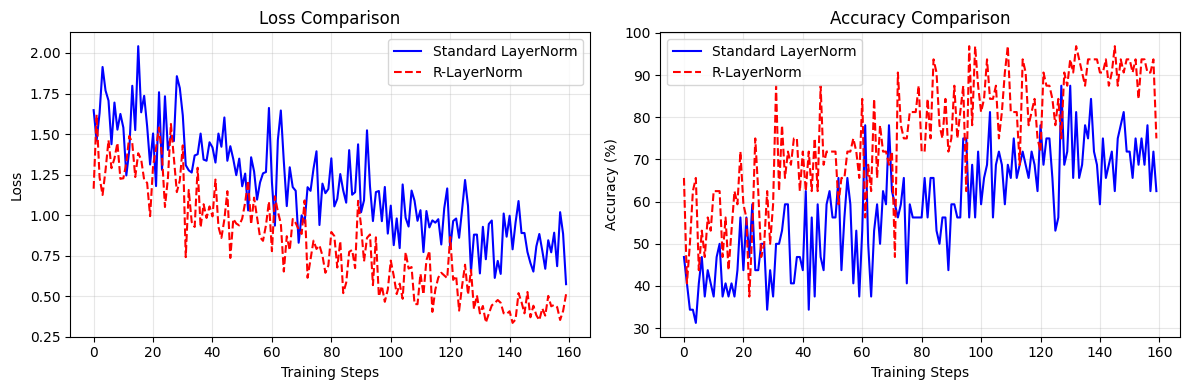

In [ ]:
import matplotlib.pyplot as plt

def plot_results(std_losses, robust_losses, std_accs, robust_accs):
    """Plot comparison graphs"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot Loss
    ax1.plot(std_losses, label='Standard LayerNorm', color='blue')
    ax1.plot(robust_losses, label='R-LayerNorm', color='red', linestyle='--')
    ax1.set_xlabel('Training Steps')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot Accuracy
    ax2.plot(std_accs, label='Standard LayerNorm', color='blue')
    ax2.plot(robust_accs, label='R-LayerNorm', color='red', linestyle='--')
    ax2.set_xlabel('Training Steps')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Accuracy Comparison')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Modify quick_test to collect metrics
def quick_test_with_metrics(model, data_loader, epochs=5):
    """Training that collects loss and accuracy"""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []
    accuracies = []

    for epoch in range(epochs):
        for batch_idx, (data, target) in enumerate(data_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            # Calculate accuracy
            _, predicted = torch.max(output.data, 1)
            accuracy = (predicted == target).float().mean().item() * 100

            losses.append(loss.item())
            accuracies.append(accuracy)

            if batch_idx % 50 == 0:
                print(f'Epoch {epoch}, Batch {batch_idx}, Loss: {loss.item():.4f}, Acc: {accuracy:.2f}%')

    return losses, accuracies

# Run with metrics collection
print("=== Testing Standard LayerNorm ===")
std_losses, std_accs = quick_test_with_metrics(std_model, train_loader)

print("\n=== Testing R-LayerNorm ===")
robust_losses, robust_accs = quick_test_with_metrics(robust_model, train_loader)

# Plot the comparison
print("\n=== Visualization Results ===")
plot_results(std_losses, robust_losses, std_accs, robust_accs)

# Model Test


In [ ]:
def test_model(model, data, labels, batch_size=32):
    """Test a trained model on new data and return accuracy"""
    model.eval()  # Set to evaluation mode
    device = next(model.parameters()).device

    # Convert data to tensor
    data_tensor = torch.tensor(data).float().permute(0, 3, 1, 2) / 255.0
    labels_tensor = torch.tensor(labels)

    dataset = TensorDataset(data_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    correct = 0
    total = 0

    with torch.no_grad():
        for batch_data, batch_labels in dataloader:
            batch_data, batch_labels = batch_data.to(device), batch_labels.to(device)

            outputs = model(batch_data)
            _, predicted = torch.max(outputs.data, 1)

            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

# Run For More Corruptions (Strengthen Results)

In [ ]:
corruptions = ['gaussian_noise', 'shot_noise', 'impulse_noise',
               'defocus_blur', 'frost', 'contrast']
results = {}

for corruption in corruptions:
    # Load different corruption
    data, labels = load_cifar10c_corruption(corruption, severity=3)
    # Test both models
    std_acc = test_model(std_model, data, labels)
    robust_acc = test_model(robust_model, data, labels)
    results[corruption] = (std_acc, robust_acc)

# Calculate Average Improvement

In [ ]:
avg_improvement = np.mean([(robust-std) for std, robust in results.values()])
print(f"Average accuracy improvement: {avg_improvement:.2f}%")

Average accuracy improvement: -9.52%
